In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
class VAE(nn.Module):
    """
    Variational Autoencoder.
    Learns a probabilistic latent space with mean (mu) and variance (logvar).
    Uses reparameterization trick for backpropagation through sampling.
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()

        # Encoder: outputs mu and logvar for latent distribution
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )

        # Separate heads for mu and logvar
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        """Encode input to latent distribution parameters."""
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: z = mu + sigma * epsilon
        This makes sampling differentiable.
        """
        std = torch.exp(0.5 * logvar) # need to root the var for sd
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        """Decode latent vector to reconstruction."""
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

In [4]:
def vae_loss(x, x_recon, mu, logvar, beta: float = 1.0):
    """
    VAE loss = Reconstruction loss + KL divergence

    Args:
        x: Original input
        x_recon: Reconstructed input
        mu: Mean of latent distribution
        logvar: Log variance of latent distribution
        beta: Weight for KL term (beta-VAE uses beta > 1)

    Returns:
        Total loss, reconstruction loss, KL loss
    """
    # Reconstruction loss (BCE for binary/normalized data)
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum')

    # KL divergence: D_KL(q(z|x) || p(z)) where p(z) = N(0, 1)
    # Formula: -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

In [9]:
def train_vae(epochs: int):
    """Example training loop for VAE on MNIST."""
    # Hyperparameters
    input_dim = 28 * 28
    latent_dim = 64
    batch_size = 128
    epochs = epochs
    lr = 1e-3

    # Device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Data
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Model
    model = VAE(input_dim, latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Training
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.view(-1, input_dim).to(device)

            optimizer.zero_grad()
            recon, mu, logvar = model(data)
            loss, recon_loss, kl_loss = vae_loss(data, recon, mu, logvar)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader.dataset)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

    return model

In [10]:
model = train_vae(20)

Epoch 1/20, Loss: 194.0625
Epoch 2/20, Loss: 146.6248
Epoch 3/20, Loss: 130.3944
Epoch 4/20, Loss: 120.9762
Epoch 5/20, Loss: 116.6490
Epoch 6/20, Loss: 113.8158
Epoch 7/20, Loss: 111.5624
Epoch 8/20, Loss: 109.9212
Epoch 9/20, Loss: 108.8378
Epoch 10/20, Loss: 107.9582
Epoch 11/20, Loss: 107.1767
Epoch 12/20, Loss: 106.4584
Epoch 13/20, Loss: 105.8324
Epoch 14/20, Loss: 105.3583
Epoch 15/20, Loss: 104.9270
Epoch 16/20, Loss: 104.5608
Epoch 17/20, Loss: 104.2722
Epoch 18/20, Loss: 103.9929
Epoch 19/20, Loss: 103.7137
Epoch 20/20, Loss: 103.4307


In [7]:
def generate_samples(vae_model, num_samples: int = 16, latent_dim: int = 20):
    """Generate new samples from a trained VAE by sampling from latent space."""
    device = next(vae_model.parameters()).device
    vae_model.eval()

    with torch.no_grad():
        # Sample from standard normal (prior)
        z = torch.randn(num_samples, latent_dim).to(device)
        samples = vae_model.decode(z)

    return samples.view(num_samples, 1, 28, 28)

samples = generate_samples(model)

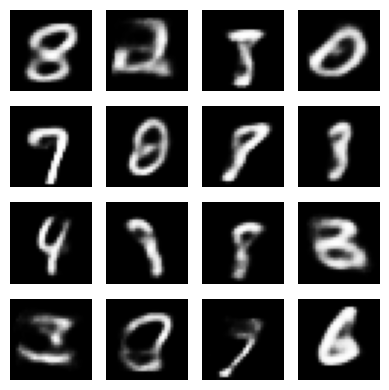

In [8]:
import matplotlib.pyplot as plt

def show_samples(samples, num_rows=4, num_cols=4):
    """Displays VAE samples in a grid."""
    plt.figure(figsize=(4, 4))
    for i in range(len(samples)):
        plt.subplot(num_rows, num_cols, i + 1)
        # Remove channel dim and move to CPU for plotting
        img = samples[i].squeeze().cpu().detach().numpy()
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(samples)